In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
num_classes = 10

epochs = 50

learning_rate = 0.001
batch_size = 128
display_step = 1

out_channel1 = 16
out_channel2 = 32

check_point = "./checkpoint.pth"

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [4]:
model = nn.Sequential(
    nn.Conv2d(1, out_channel1, kernel_size = 5, stride = 1, padding = 2),
    nn.ReLU(),
    nn.Conv2d(out_channel1, out_channel2, kernel_size = 5, stride = 1, padding = 2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2, stride = 2),
    nn.Dropout(0.2),
    nn.Flatten(),
    nn.Linear(out_channel2 * 14 * 14, num_classes),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(num_classes, num_classes),
    nn.Softmax(dim=1),
)

try:
    model.load_state_dict(torch.load(check_point))
    print("Model loaded successfully.")
except:
    print("No checkpoint found. Starting training from scratch.")

Model loaded successfully.


/tmp/ipykernel_118014/3687546871.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(check_point))


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = learning_rate, weight_decay = 1e-5)
best_val_loss = float('inf')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
import tqdm
for epoch in range(epochs):
    model.train()
    for i, (images, labels) in enumerate(tqdm.tqdm(train_loader)):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch + 1) % display_step == 0:
        model.eval()
        with torch.no_grad():
            val_loss = 0
            correct = 0
            total = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
            val_loss /= len(test_loader)
            accuracy = correct / total
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}, Accuracy: {accuracy:.4f}')
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), check_point)
                print("Model checkpoint saved.")
model.load_state_dict(torch.load(check_point))

100%|██████████| 469/469 [00:08<00:00, 58.38it/s]


Epoch [1/50], Loss: 1.5774, Val Loss: 1.5003, Accuracy: 0.9620
Model checkpoint saved.


100%|██████████| 469/469 [00:07<00:00, 62.56it/s]


Epoch [2/50], Loss: 1.5686, Val Loss: 1.4999, Accuracy: 0.9623
Model checkpoint saved.


100%|██████████| 469/469 [00:07<00:00, 61.46it/s]


...

Epoch [49/50], Loss: 1.5650, Val Loss: 1.4776, Accuracy: 0.9839


100%|██████████| 469/469 [00:07<00:00, 65.76it/s]


Epoch [50/50], Loss: 1.5360, Val Loss: 1.4764, Accuracy: 0.9851


/tmp/ipykernel_118014/1800051703.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(check_point))


<All keys matched successfully>

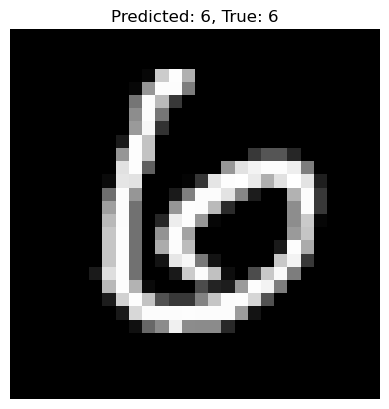

In [11]:
item = iter(test_loader)

data, label = next(item)

test_idx = random.choice(range(len(data)))

data = data[test_idx].unsqueeze(0)

label = label[test_idx].item()

assert data.shape == (1, 1, 28, 28)



def plot_image(data, model, label):
    model.to(device)
    model.eval()
    with torch.no_grad():
        data = data.to(device)
        output = model(data).cpu()
        predicted_label = torch.argmax(output, dim=1).item()
    plt.imshow(data.cpu().squeeze(), cmap='gray')
    plt.title(f'Predicted: {predicted_label}, True: {label}')
    plt.axis('off')
    plt.show()
plot_image(data, model, label)


100%|██████████| 79/79 [00:01<00:00, 52.11it/s]


Done.
Test Accuracy: 0.9856
Total wrong samples: 144


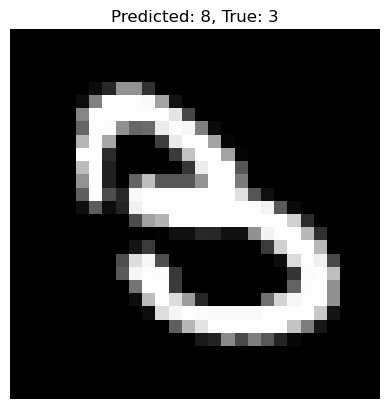

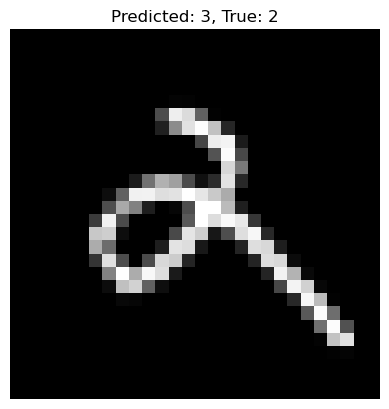

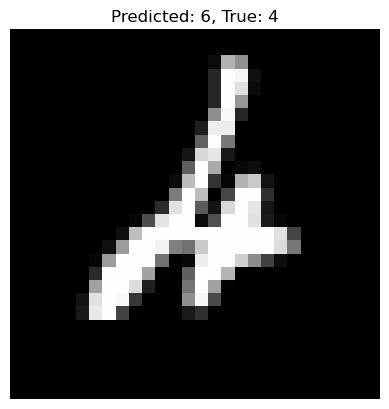

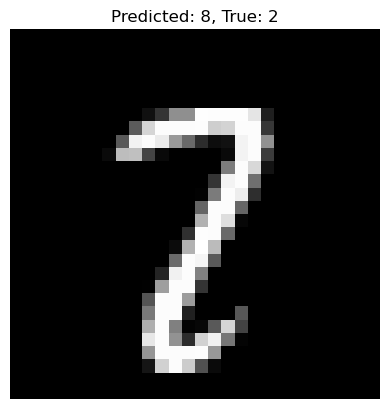

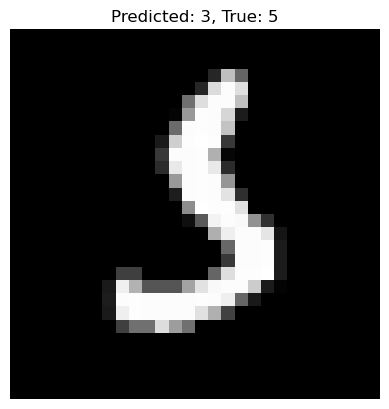

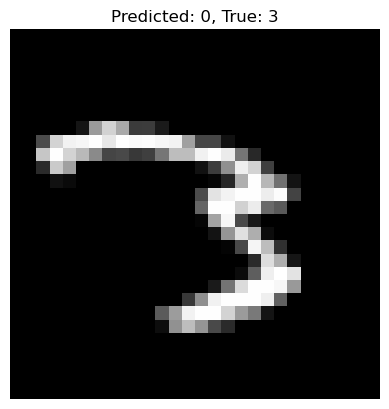

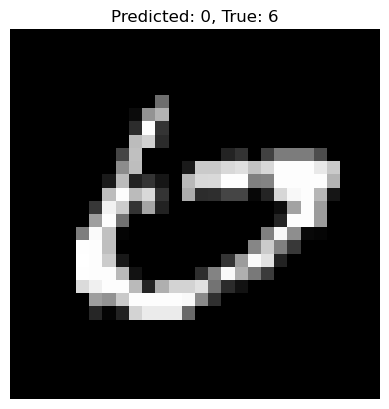

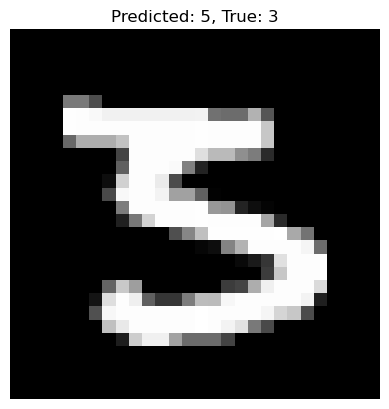

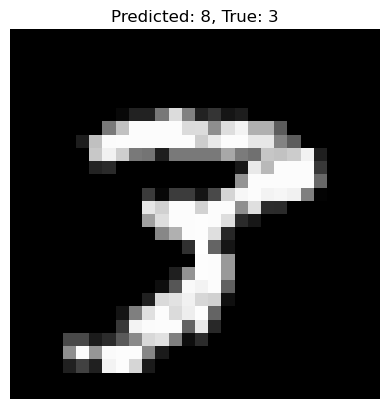

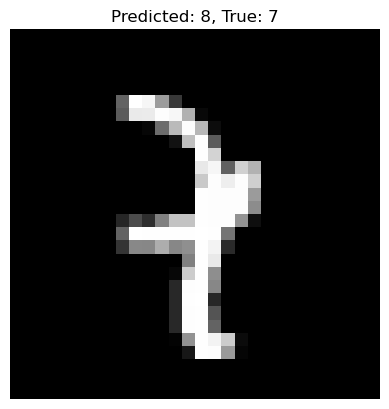

In [16]:
model.to(device)

model.eval()
acc = 0
total = 0
wrong_samples = []
for (images, labels) in tqdm.tqdm(test_loader):

    images, labels = images.to(device), labels.to(device)

    outputs = model(images)

    _, predicted = torch.max(outputs.data, 1)
    acc += (predicted == labels).sum().item()
    total += labels.size(0)

    for i in range(len(predicted)):

        if predicted[i] != labels[i]:
            wrong_samples.append((images[i:i+1].cpu(), labels[i].item(), predicted[i].item()))


print("Done.")
print(f"Test Accuracy: {acc / total:.4f}")
print(f"Total wrong samples: {len(wrong_samples)}")
for i in range(min(10, len(wrong_samples))):
    img, true_label, pred_label = wrong_samples[i]
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'Predicted: {pred_label}, True: {true_label}')
    plt.axis('off')
    plt.show()